In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *
from NicolasSamson.script.extractors import * 
from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]


In [32]:

def create_dataframe_for_diamond_shape_graph(df_slip_dataset,terrain,robot,traction,offline_localisation):
    # Steady state keeping
    df_steady_state = df_slip_dataset[df_slip_dataset['steady_state_mask'] == 1]
    print(df_steady_state.shape)


    # Remove the first window
    df_last_window = df_steady_state.drop_duplicates(subset=['steady_state_mask','calib_step'],keep='last')
    #print(df_last_window.shape)

    print(df_last_window.shape)
    
    cmd_left = np.mean(column_type_extractor(df_last_window, 'cmd_l',verbose=False),axis=1)
    cmd_right = np.mean(column_type_extractor(df_last_window, 'cmd_r',verbose=False),axis=1)
    cmd_vel = np.vstack((cmd_left,cmd_right))
    body_vel = compute_body_vel_IDD(cmd_vel , robot='warthog-wheel')

    icp_vel_x = np.mean(column_type_extractor(df_last_window, 'icp_vel_x',verbose=False),axis=1)
    icp_vel_y = np.mean(column_type_extractor(df_last_window, 'icp_vel_y',verbose=False),axis=1)
    icp_vel_yaw = np.mean(column_type_extractor(df_last_window, 'icp_vel_yaw',verbose=False),axis=1)
    body_vel_icp_mean = np.vstack((icp_vel_x,icp_vel_yaw))

    raw_icp_vel_x_mean = np.mean(column_type_extractor(df_last_window, 'raw_icp_vel_x',verbose=False),axis=1)
    raw_icp_vel_yaw_mean = np.mean(column_type_extractor(df_last_window, 'raw_icp_vel_yaw',verbose=False),axis=1)


    odom_speed_l = np.mean(column_type_extractor(df_last_window, 'left_wheel_vel',verbose=False),axis=1)
    odom_speed_right = np.mean(column_type_extractor(df_last_window, 'right_wheel_vel',verbose=False),axis=1)

    body_slip_x =  body_vel[0,:] - icp_vel_x
    body_slip_yaw = body_vel[1,:] -icp_vel_yaw 

    size = odom_speed_l.shape[0]
    dictionnary_ = {"terrain": [terrain] * size,
                    "robot": [robot] * size,
                    "traction": [traction] * size,
                    "offline_localisation":[offline_localisation]*size,
                    "cmd_left_wheels":cmd_left,
                    "cmd_right_wheels":cmd_right,
                    "cmd_body_x":body_vel[0,:],
                    "cmd_body_yaw":body_vel[1,:],
                    "icp_vel_x_smoothed":icp_vel_x,
                    "icp_vel_yaw_smoothed":icp_vel_yaw,
                    "raw_icp_vel_x_mean":raw_icp_vel_x_mean,
                    "raw_icp_vel_yaw_mean":raw_icp_vel_yaw_mean,
                    "odom_speed_left_wheels": odom_speed_l,
                    "odom_speed_right_wheels": odom_speed_right,
                    "slip_body_x_ss": body_slip_x,
                    "slip_body_yaw_ss": body_slip_yaw,
                    "slip_body_y_ss": icp_vel_y,
                    "slip_wheel_left_ss": cmd_left-odom_speed_l,
                    "slip_wheel_right_ss": cmd_right-odom_speed_right,
                    }

    df = pd.DataFrame.from_dict(dictionnary_)


    verbose=True
    if verbose ==True:
        print(f"cmd_shape {cmd_vel.shape}")
        print(f"body_vel_icp_mean {body_vel_icp_mean.shape}")
    return df


In [17]:
def combine_terrain_dataset(param_array,path_2_save ="/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets"):

    list_df = []
    
    for params in param_array:
        df_slip = pd.read_pickle(params["path_2_dataset"])

        df = create_dataframe_for_diamond_shape_graph(df_slip,params["terrain"],params["robot"],params["traction"],
                                                    params["offline_localisation"])
        
        list_df.append(df)

    df = pd.concat(list_df)

    path_to_save  = pathlib.Path(path_2_save)/"all_terrain_diamond_shape_graph_data.pkl"
    df.to_pickle(str(path_to_save))
    return df 

In [70]:
param_gravel = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/ice/ral2023/model_training_datasets/acceleration_dataset.pkl',
    "terrain":"gravel",
    "offline_localisation":True,
    "robot":"warthog",
    "traction":"wheels"
}

param_ice = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/gravel/ral2023/model_training_datasets/acceleration_dataset.pkl',
    "color_background":"lightblue",
    "terrain":"ice",
    "offline_localisation":True,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_1 = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_7_10h31s34/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_2 = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_7_11h30s30/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_3_focus_on_low_speed = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_8_11h46s24/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}


list_params = [param_asphalt_1,param_asphalt_2,param_gravel,param_ice]

In [71]:
df_all_combined = combine_terrain_dataset(list_params)

(200, 1218)
(100, 1218)
cmd_shape (2, 100)
body_vel_icp_mean (2, 100)
(200, 1218)
(100, 1218)
cmd_shape (2, 100)
body_vel_icp_mean (2, 100)
(394, 1458)
(197, 1458)
cmd_shape (2, 197)
body_vel_icp_mean (2, 197)
(240, 1458)
(120, 1458)
cmd_shape (2, 120)
body_vel_icp_mean (2, 120)


/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolassamson/.pyenv/versi

# Same graph but with many datasets




Note that the yaw angle in the the smooth version is the IMU


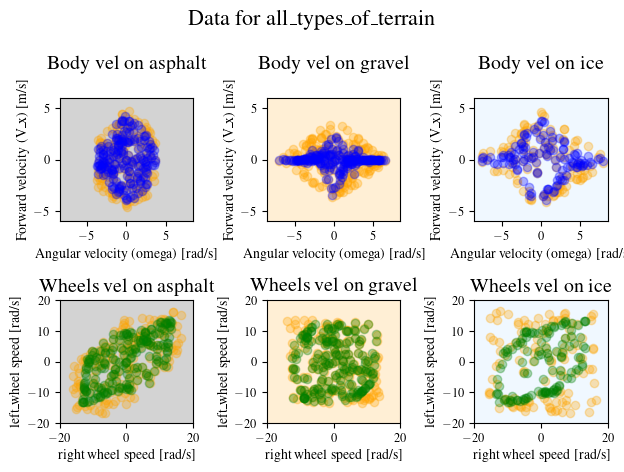

In [72]:


def plot_diamond_graph(df_all_terrain):
    color_dict = {"asphalt":"lightgrey", "ice":"aliceblue","gravel":"papayawhip"}
    list_terrain = df_all_terrain["terrain"].unique()
    size = len(list_terrain)
    fig, axs = plt.subplots(2,size)
    alpha_parama= 0.3
    y_lim = 6
    x_lim = 8.5
    
    for i in range(size):  
        terrain = list_terrain[i]
        df = df_all_terrain.loc[df_all_terrain["terrain"]==terrain]        
        axs[0][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],color = "orange",label='Body vel command',alpha=alpha_parama)
        axs[0][i].scatter(df["cmd_body_yaw"],df["icp_vel_x_smoothed"],color = "blue",label='ICP_smoothed',alpha=alpha_parama) 
        axs[0][i].set_xlabel("Angular velocity (omega) [rad/s]")
        axs[0][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #axs[0][0].legend(loc='center left')
        #axs[0][1].scatter(body_vel[1,:],body_vel[0,:],color = "orange",alpha=alpha_parama)
        #axs[0][1].scatter(raw_icp_vel_yaw_mean,raw_icp_vel_x_mean,color = "grey",label='ICP_raw',alpha=alpha_parama) 
        #axs[0][1].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[0][1].set_ylabel("Forward velocity (V_x) [m/s]")
        #axs[0][1].legend(loc='center left')

        axs[1][i].scatter(df["cmd_right_wheels"],df["cmd_left_wheels"],color="orange",label="Command",alpha=alpha_parama)
        axs[1][i].scatter(df["odom_speed_right_wheels"],df["odom_speed_left_wheels"],color="green",alpha=alpha_parama)
        axs[1][i].set_ylabel("left_wheel speed [rad/s]")
        axs[1][i].set_xlabel("right wheel speed [rad/s]")
        
        #axs[1][0].legend(loc='upper right')

        axs[0][i].set_title(f"Body vel on {terrain}\n ") # (ICP smooth by spline,yaw=imu)
        #axs[0][1].set_title("Command VS Body vel \n (ICP derivate)")
        axs[1][i].set_title(f"Wheels vel on {terrain}")

        # square plot
        #axs[0][0].axis('equal')
        #axs[0][1].axis('equal')
        wheels_value = 20
        axs[1][i].set_ylim((-wheels_value,wheels_value))
        axs[1][i].set_xlim((-wheels_value,wheels_value))
        
        axs[0][i].set_ylim((-y_lim,y_lim))
        axs[0][i].set_xlim((-x_lim,x_lim))
        #back_ground_color = df.color .unique()
        axs[0][i].set_facecolor(color_dict[terrain])
        axs[1][i].set_facecolor(color_dict[terrain])

        #fig.patches .set_facecolor()
    
    l, legends_label = axs[0][0].get_legend_handles_labels()
    
    l2, legends_label_2 = axs[1][0].get_legend_handles_labels()
    #axs[0][-1].set_axis_off()
    #axs[1][-1].set_axis_off()
    
    legends_labels = legends_label+legends_label_2

    lines = l+l2
    #axs[0][-1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0, -0.55, 1, 1),
    #            bbox_transform = plt.gcf().transFigure,ncol=3)
    fig.suptitle(f"Data for all_types_of_terrain",fontsize=16)

    #fig.patch.set_facecolor(color_background)
    plt.tight_layout()
    

    print('Note that the yaw angle in the the smooth version is the IMU')


plot_diamond_graph(df_all_combined) 

In [73]:
def scatter_plot_slip(df,column_x_y_z, ax_to_plot, cmap_name,background_terrain_dict,ylim,xlim,global_cmap,labels_xyz,alpha,show_x_label=False):

    norm_slip = mpl.colors.Normalize(0, vmax=np.abs(global_cmap[1][column_x_y_z[2]].max()))
   
    if not global_cmap[0]:
        scatter_ax = ax_to_plot.scatter(df[column_x_y_z[0]],df[column_x_y_z[1]],c = np.abs(df[column_x_y_z[2]]),cmap=cmap_name,alpha=alpha)
    else:    
        scatter_ax = ax_to_plot.scatter(df[column_x_y_z[0]],df[column_x_y_z[1]],c = np.abs(df[column_x_y_z[2]]),cmap=cmap_name,norm=norm_slip,alpha=alpha)
    
    if show_x_label:
        ax_to_plot.set_xlabel(labels_xyz[0])  
    ax_to_plot.set_ylabel(labels_xyz[1]) 
    cbar = plt.colorbar(scatter_ax, ax=ax_to_plot)
    cbar.set_label(labels_xyz[2])
    ax_to_plot.set_ylim((-ylim,ylim))
    ax_to_plot.set_xlim((-xlim,xlim))
    ax_to_plot.set_facecolor(mpl.colors.to_rgba(background_terrain_dict,0.2))



    

Note that the yaw angle in the the smooth version is the IMU


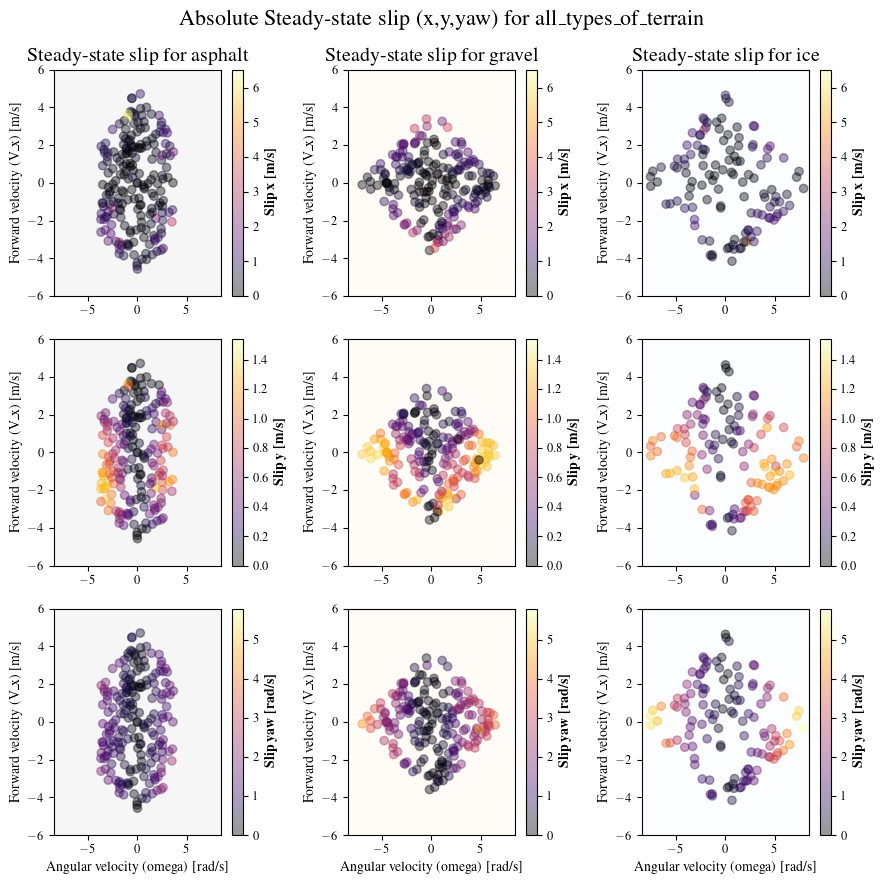

In [75]:
def plot_diamond_graph_slip_heat_map(df_all_terrain,global_cmap = True):
    color_dict = {"asphalt":"lightgrey", "ice":"aliceblue","gravel":"papayawhip"}
    list_terrain = df_all_terrain["terrain"].unique()
    size = len(list_terrain)
    fig, axs = plt.subplots(3,size)

    fig.set_figwidth(3*size)
    fig.set_figheight(3*3)
    alpha_parama= 0.3

    y_lim = 6 # m/s
    x_lim = 8.5 #m/s
    cmap = 'viridis' # 
    norm_slip_yaw = mpl.colors.Normalize(0, vmax=df_all_terrain["slip_body_yaw_ss"].max())

    norm_slip_wheel = mpl.colors.Normalize(0, 0)

    scatter_colored_plot_slip_x = []
    scatter_colored_plot_slip_yaw = []  

    global_cmap = [global_cmap,df_all_combined]
    
    alpha_scatter = 0.4
    
    for i in range(size):  
        terrain = list_terrain[i]
        
        df = df_all_terrain.loc[df_all_terrain["terrain"]==terrain]
        
        labels_xyz  = ["Angular velocity (omega) [rad/s]" , "Forward velocity (V_x) [m/s]",""] 
        column_x_y_z = ["cmd_body_yaw","cmd_body_x", "slip_body_x_ss"]
        show_x_label = False
        #### Slip x 
        if size == 1:
            ax_to_plot = axs[0]
        else:
            ax_to_plot = axs[0,i]
        
        labels_xyz[2] = r"$\textbf{Slip x [m/s]}$"
        scatter_plot_slip(df, column_x_y_z, ax_to_plot, "inferno", color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
       
        ##### Slip y 
        
        column_x_y_z[2] = "slip_body_y_ss"

        if size == 1:
            ax_to_plot = axs[1]
        else:
            ax_to_plot = axs[1,i]
        labels_xyz[2] = r"$\textbf{Slip y [m/s]}$"
        ######### slip y  ####################
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        


        ### Slip yaw 
        column_x_y_z[2] = "slip_body_yaw_ss"
        show_x_label = True
        if size == 1:
            ax_to_plot = axs[2]
        else:
            ax_to_plot = axs[2,i]
        ######### slip y  ####################
        labels_xyz[2] = r"$\textbf{Slip yaw [rad/s]}$"
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        

        axs[0][i].set_title(f"Steady-state slip for {terrain}") # (ICP smooth by spline,yaw=imu)
        

        #if not global_cmap:
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",alpha=0.2))
        #else:    
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",norm=norm_slip_yaw,alpha=0.2))
        #axs[2][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[2][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[2, i])
        #cbar.set_label('Yaw slip')
        #axs[2][i].set_ylim((-y_lim,y_lim))
        #axs[2][i].set_xlim((-x_lim,x_lim))
        #axs[2][i].set_facecolor(color_dict[terrain])


        #axs[1][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[1][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar1 = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[1, i])
        #cbar1.set_label('Yaw slip')
        #axs[1][i].set_title(f"Wheels slip {terrain}")
        #wheels_value = 20
        #axs[1][i].set_ylim((-wheels_value,wheels_value))
        #axs[1][i].set_xlim((-wheels_value,wheels_value))
        
        

        #fig.patches .set_facecolor()
        

    l, legends_label = axs[0][0].get_legend_handles_labels()
    
    l2, legends_label_2 = axs[1][0].get_legend_handles_labels()
    #axs[0][-1].set_axis_off()
    #axs[1][-1].set_axis_off()
    
    legends_labels = legends_label+legends_label_2

    
    lines = l+l2
    #axs[0][-1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0, -0.55, 1, 1),
    #            bbox_transform = plt.gcf().transFigure,ncol=3)
    fig.suptitle(f"Absolute Steady-state slip (x,y,yaw) for all_types_of_terrain",fontsize=16)

    #fig.patch.set_facecolor(color_background)
    
    fig.tight_layout()

    print('Note that the yaw angle in the the smooth version is the IMU')



plot_diamond_graph_slip_heat_map(df_all_combined,global_cmap=True)

Axes(0.547727,0.653529;0.352273x0.226471)


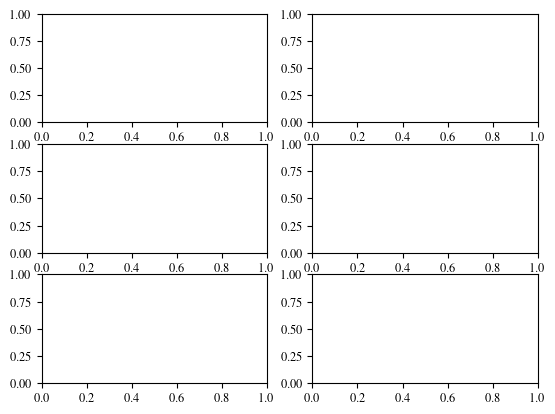

In [25]:
fig,axs = plt.subplots(3,2)
print(axs[0,1])

TypeError: 'Axes' object is not subscriptable

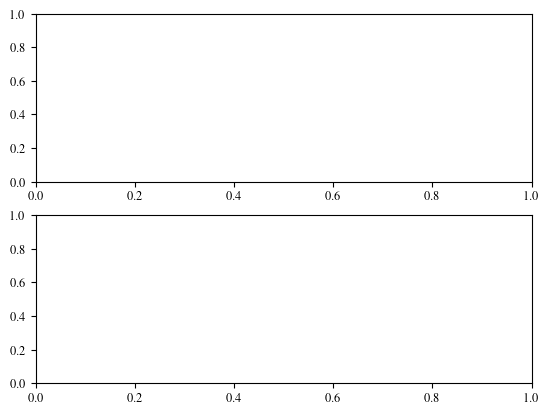

In [82]:
df_aphalt = df_all_combined.loc[df_all_combined["terrain"]  == "asphalt"]

plot_diamond_graph_slip_heat_map(df_aphalt)

In [8]:
def create_heat_images_from_slip(df,column_x,comun_y,discretization_x,discretizaqtion_y):
    y_lim = 6 # m/s
    x_lim = 8.5 #m/s
    
    n_size_y = int(y_lim*2 /discretization_x + 1)

    
    n_size_x = int(y_lim*2 /discretization_x + 1)

    y = np.linspace(-y_lim,y_lim,n_size_y)
    x = np.linspace(-x_lim,x_lim,n_size_x)

    yaw_cmd_mesh,x_cmd_mesh = np.meshgrid(x,y)

    np_cmd_count = np.zeros((n_size_x,n_size_y))
    np_cmd_sum = np.zeros((n_size_x,n_size_y))

    for yaw_cmd in yaw_cmd_mesh:

        for x_cmd in x_cmd_mesh: 
            
            mask = (df[column_x] >= yaw_cmd -discretization_x/2) & (df[column_x] < yaw_cmd + discretization_yaw/2) & (df[column_y] > x_cmd - discretization_x/2) & (df[column_y] < x_cmd + discretization_yaw/2)

            
    df_all_combined

discretization_x = 0.10 #m/s
discretization_yaw = 0.10 # rad/s

column_x = "cmd_body_yaw"
column_y = "cmd_body_x"

create_heat_images_from_slip(df_all_combined["gravel"],column_x,column_y,discretization_x,discretizaqtion_y)
        

KeyError: 'gravel'